In [5]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv")

In [3]:
df.to_csv("car_fuel_efficiency.csv",index=False)

In [9]:
df.head().T

,0,1,2,3,4
engine_displacement,170,130,170,220,210
num_cylinders,3.0,5.0,0.0,4.0,1.0
horsepower,159.0,97.0,78.0,0.0,140.0
vehicle_weight,3413.433759,3149.664934,3079.038997,2542.392402,3460.87099
acceleration,17.7,17.8,15.1,20.2,14.4
model_year,2003,2007,2018,2009,2009
origin,Europe,USA,Europe,USA,Europe
fuel_type,Gasoline,Gasoline,Gasoline,Diesel,Gasoline
drivetrain,All-wheel drive,Front-wheel drive,Front-wheel drive,All-wheel drive,All-wheel drive
num_doors,0.0,0.0,0.0,2.0,2.0


## Preparing the dataset
Preparation:

- Fill missing values with zeros. </br>
- Do train/validation/test split with 60%/20%/20% distribution.</br>
- Use the train_test_split function and set the random_state parameter to 1.</br>
- Use DictVectorizer(sparse=True) to turn the dataframes into matrices.</br>


In [7]:
df = pd.read_csv("car_fuel_efficiency.csv")

In [8]:
df=df.fillna(0)

In [16]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = (df_train.fuel_efficiency_mpg).values
y_val = (df_val.fuel_efficiency_mpg).values
y_test = (df_test.fuel_efficiency_mpg).values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [17]:
from sklearn.feature_extraction import DictVectorizer

train_dicts = df_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

## Question 1
Let's train a decision tree regressor to predict the fuel_efficiency_mpg variable.

Train a model with max_depth=1.
Which feature is used for splitting the data?

#### Answer: 'vehicle_weight'


In [27]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=1, max_depth=1) # random_state for reproducibility
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [28]:
from sklearn.tree import export_text
print(export_text(model, feature_names=list(dv.get_feature_names_out())))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



## Question 2
Train a random forest regressor with these parameters:

n_estimators=10, random_state=1, n_jobs=-1 (optional - to make training faster)

What's the RMSE of this model on the validation data?

#### Answer: 0.45


In [20]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=10, random_state=1,n_jobs=-1)
regressor.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
from sklearn.metrics import mean_squared_error, r2_score

val_dicts = df_val.to_dict(orient='records')

X_val = dv.transform(val_dicts)

predictions = regressor.predict(X_val)

mse = mean_squared_error(y_val, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, predictions)

print("MSE: ",mse)
print("R2: ",r2)
print("RMSE",rmse)

MSE:  0.21248552697499765
R2:  0.9684068956815364
RMSE 0.4609615243976417


## Question 3
Now let's experiment with the n_estimators parameter

Try different values of this parameter from 10 to 200 with step 10. </br>
Set random_state to 1. </br>
Evaluate the model on the validation dataset. </br> 

</br>
After which value of n_estimators does RMSE stop improving? Consider 3 decimal places for calculating the answer.</br>

#### Answer: 200 If it doesn't stop improving, use the latest iteration number in your answer.



In [38]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    scores.append((n, rmse, round(rmse,3)))

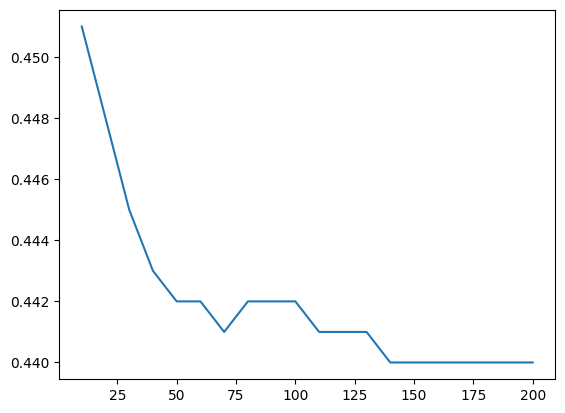

In [39]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse','r_rmse'])
plt.plot(df_scores.n_estimators, df_scores.r_rmse)
#plt.ylim(0.4425, 0.455)

## Question 4
Let's select the best max_depth: </br>

Try different values of max_depth: [10, 15, 20, 25]</br>
For each of these values,</br>
try different values of n_estimators from 10 till 200 (with step 10)</br>
calculate the mean RMSE</br>
Fix the random seed: random_state=1</br>
What's the best max_depth, using the mean RMSE?</br>

#### Answer: 10


In [40]:
scores = []

depths =  [10, 15, 20, 25]

for d in depths:
    for n in range(10, 201, 10):
        dt = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=1, n_jobs=-1)
        dt.fit(X_train, y_train)
        y_pred = dt.predict(X_val)
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        scores.append((d,n,rmse))

In [41]:
df_scores = pd.DataFrame(scores, columns=['max_depth','n_estimators', 'rmse'])
df_scores.groupby('max_depth')['rmse'].mean().sort_values(ascending=True)

max_depth
10    0.442045
15    0.445431
20    0.446181
25    0.446613
Name: rmse, dtype: float64

## Question 5
We can extract feature importance information from tree-based models.</br>

At each step of the decision tree learning algorithm, it finds the best split. When doing it, we can calculate "gain" - the reduction in impurity before and after the split. This gain is quite useful in understanding what are the important features for tree-based models.</br>

In Scikit-Learn, tree-based models contain this information in the feature_importances_ field.</br>

For this homework question, we'll find the most important feature:</br>

Train the model with these parameters:</br>
n_estimators=10,</br>
max_depth=20,</br>
random_state=1,</br>
n_jobs=-1 (optional)</br>
Get the feature importance information from this model</br>
What's the most important feature (among these 4)?</br>


#### Answer: vehicle_weight


In [44]:
model = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
model.fit(X_train, y_train)

feature_importances = model.feature_importances_

# Print the feature importances
feature_importances = pd.Series(feature_importances, index=dv.get_feature_names_out()).sort_values(ascending=False)

# 7. Print the results
print("Feature Importances:")
print(feature_importances)
    

Feature Importances:
vehicle_weight                  0.959177
horsepower                      0.016020
acceleration                    0.011493
engine_displacement             0.003282
model_year                      0.003194
num_cylinders                   0.002331
num_doors                       0.001610
origin=USA                      0.000551
origin=Europe                   0.000521
origin=Asia                     0.000462
fuel_type=Diesel                0.000373
drivetrain=All-wheel drive      0.000364
drivetrain=Front-wheel drive    0.000314
fuel_type=Gasoline              0.000309
dtype: float64


## Question 6
Now let's train an XGBoost model! For this question, we'll tune the eta parameter: </br>

Install XGBoost </br>
Create DMatrix for train and validation </br>
Create a watchlist </br>
Train a model with these parameters for 100 rounds: </br>

Now change eta from 0.3 to 0.1.

Which eta leads to the best RMSE score on the validation dataset?

#### Answer: 0.1


In [50]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

In [46]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 42.0 MB/s eta 0:00:00m eta 0:00:010:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 38.4 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]━━━ 1/2 [xgboost]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [62]:
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(eta= 0.1, 
    max_depth= 6,
    min_child_weight= 1,
    objective= 'reg:squarederror',
    nthread= 8,
    n_estimators=100, 
    seed= 1,
    verbosity=1)

model = xgb_reg.fit(X_train,y_train)

In [63]:
y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
rmse

np.float64(0.42622800553359225)